# LMS Data — Exploratory Data Analysis
**Project:** Weis Markets L&D Impact Analysis  
**Dataset:** `lms_synthetic_validated_100k.csv` (100,000 training records)  
**Goal:** Understand the structure, quality, and patterns in the LMS data before merging with revenue.

## LMS Dataset — Data Dictionary

| Variable Name | Category | Description |
|---|---|---|
| `Employee ID` | Identity | Unique identifier for each employee across all training records |
| `First Name` | Identity | Employee first name |
| `Last Name` | Identity | Employee last name |
| `Full Name` | Identity | Concatenated first and last name |
| `Email Address` | Identity | Employee work email address |
| `Hire Date` | Workforce | Date the employee was hired; used to derive tenure at time of training assignment |
| `Business Unit` | Organizational | High-level division the employee belongs to (e.g. Store Operations, Corporate Services) |
| `District` | Organizational | Regional grouping of stores (e.g. East_District_01); links stores to a shared management structure |
| `Location` | Organizational | Store or site identifier (e.g. Store_001, HQ_001); matches `Store_ID` in the revenue dataset and serves as the join key |
| `Department` | Organizational | Functional department within the store or business unit (e.g. Produce, Store Management, Compliance) |
| `Job Code` | Organizational | Standardized role code classifying the employee's position level |
| `Supervisor Employee ID` | Organizational | Employee ID of the direct supervisor; used to map reporting structure |
| `Supervisor Name` | Organizational | Full name of the employee's direct supervisor |
| `Supervisor Email Address` | Organizational | Work email of the direct supervisor |
| `FullTimePartTime` | Workforce | Employment classification: `Full Time` or `Part Time` |
| `Is Salaried` | Workforce | Indicates whether the employee is on a salaried (`Yes`) or hourly (`No`) pay structure |
| `Learning Module Code` | Module | Unique code identifying the training module (e.g. CMP001, OPS007) |
| `Learning Module Name` | Module | Descriptive title of the training module |
| `Learning Module Type` | Module | Delivery format of the module: `eLearning`, `Instructor-Led`, `Assessment`, or `Microlearning` |
| `Learning Module Category` | Module | Content area the module belongs to: `Compliance`, `Operations`, `Safety`, `Leadership`, `Sales`, `Customer Experience`, `Technology`, `Human Resources`, or `Analytics` |
| `Estimated Duration` | Module | Expected time to complete the module, in minutes, as set by the L&D team |
| `Progress Instance` | Assignment Tracking | Sequential instance number for repeated assignments of the same module to the same employee |
| `Progress ID` | Assignment Tracking | Unique identifier for each individual training record (one row = one employee × one module instance) |
| `Assignment Type` | Assignment Tracking | How the training was assigned: `Required`, `Elective`, `Recommended`, or `Manager Assigned` |
| `Assignment Date` | Assignment Tracking | Date the training module was assigned to the employee |
| `Due Date` | Assignment Tracking | Deadline by which the module must be completed |
| `Complete Date` | Assignment Tracking | Date the employee marked the module as complete; null if not yet completed |
| `Progress Status` | Assignment Tracking | Current completion state: `Completed`, `In Progress`, or `Not Started` |
| `Past Due` | Assignment Tracking (Derived) | Indicates whether the module was completed or remains incomplete past the `Due Date`: `Yes` or `No` |
| `Days Past Due` | Assignment Tracking (Derived) | Number of days the assignment is overdue; 0 for on-time or incomplete records not yet past the deadline |
| `Total Time` | Engagement | Actual time the employee spent on the module in minutes, as logged by the LMS |
| `Satisfied` | Engagement | Post-completion satisfaction rating reported by the employee: `Yes` (satisfied) or `No` (not satisfied) |

## 1. Setup & Load

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('datasets/lms_synthetic_calibrated.csv',
                 parse_dates=['Hire Date', 'Assignment Date', 'Due Date', 'Complete Date'])

print(f'Shape: {df.shape}')
df.head(3)

## 2. Data Overview

In [2]:
# Column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Employee ID               100000 non-null  int64         
 1   First Name                100000 non-null  object        
 2   Last Name                 100000 non-null  object        
 3   Full Name                 100000 non-null  object        
 4   Hire Date                 100000 non-null  datetime64[ns]
 5   Learning Module Code      100000 non-null  object        
 6   Learning Module Name      100000 non-null  object        
 7   Learning Module Type      100000 non-null  object        
 8   Learning Module Category  100000 non-null  object        
 9   Estimated Duration        100000 non-null  int64         
 10  Progress Instance         100000 non-null  int64         
 11  Progress ID               100000 non-null  object        
 12  Ass

In [3]:
# Numeric summary
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
Employee ID,100000.00,1004220.83,2460.56,1000001.00,1002091.00,1004220.00,1006351.00,1008474.00
Estimated Duration,100000.00,31.61,23.15,7.00,14.00,26.00,41.00,114.00
Progress Instance,100000.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00
Total Time,100000.00,25.51,23.22,0.00,10.00,19.00,34.00,185.00
Days Past Due,100000.00,76.06,172.98,0.00,0.00,0.00,40.00,812.00
Supervisor Employee ID,99988.00,1000145.84,73.39,1000001.00,1000082.00,1000146.00,1000209.00,1000272.00


In [4]:
# Categorical cardinality — how many unique values per categorical column
cat_cols = df.select_dtypes(include='object').columns.tolist()
cardinality = pd.DataFrame({
    'dtype': df[cat_cols].dtypes,
    'unique_values': df[cat_cols].nunique(),
    'sample_values': [df[c].dropna().unique()[:5].tolist() for c in cat_cols]
})
display(cardinality)

,dtype,unique_values,sample_values
First Name,object,644,"[Danielle, Joshua, Jill, Patricia, Robert]"
Last Name,object,982,"[Johnson, Walker, Rhodes, Miller, Wagner]"
Full Name,object,8009,"[Danielle Johnson, Joshua Walker, Jill Rhodes,..."
Learning Module Code,object,73,"[CEX001, LDR002, CMP009, OPS007, CMP004]"
Learning Module Name,object,73,"[Customer Greeting Standards, Leading Through ..."
Learning Module Type,object,4,"[Instructor-Led, Assessment, eLearning, Microl..."
Learning Module Category,object,9,"[Customer Experience, Leadership, Compliance, ..."
Progress ID,object,100000,"[PRG0000005, PRG0000012, PRG0000010, PRG000000..."
Assignment Type,object,4,"[Elective, Required, Recommended, Manager Assi..."
Progress Status,object,3,"[Not Started, Completed, In Progress]"


## 3. Missing Values

,missing_count,pct
Complete Date,21787,21.79
Satisfied,21787,21.79
Supervisor Employee ID,12,0.01
Supervisor Name,12,0.01
Supervisor Email Address,12,0.01


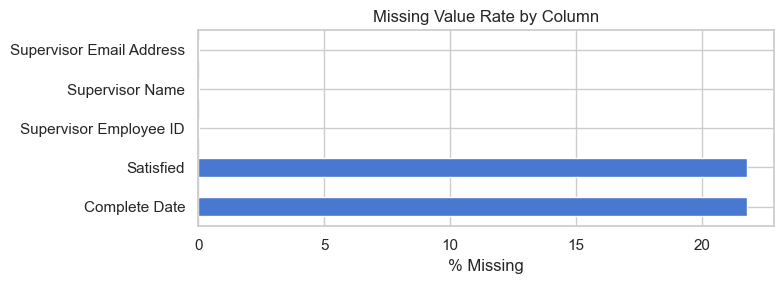

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print('No missing values found.')
else:
    pct = (missing / len(df) * 100).round(2)
    display(pd.DataFrame({'missing_count': missing, 'pct': pct}))

    fig, ax = plt.subplots(figsize=(8, max(3, len(missing) * 0.4)))
    pct.plot(kind='barh', ax=ax)
    ax.set_xlabel('% Missing')
    ax.set_title('Missing Value Rate by Column')
    plt.tight_layout()
    plt.show()

## 4. Feature Engineering

In [6]:
# Reference date: use the latest Assignment Date in the data
ref_date = df['Assignment Date'].max()

# Tenure at time of assignment (years)
df['Tenure_Years'] = ((df['Assignment Date'] - df['Hire Date']).dt.days / 365.25).round(1)

# Time ratio: actual / estimated (>1 = spent more time than expected)
df['Time_Ratio'] = (df['Total Time'] / df['Estimated Duration']).replace([np.inf, -np.inf], np.nan)

# Days from assignment to completion (only for completed records)
df['Days_to_Complete'] = (df['Complete Date'] - df['Assignment Date']).dt.days

# Completion flag
df['Is_Completed'] = (df['Progress Status'] == 'Completed').astype(int)

# Satisfied as binary
df['Satisfied_Binary'] = (df['Satisfied'] == 'Yes').astype(int)

print('New columns added: Tenure_Years, Time_Ratio, Days_to_Complete, Is_Completed, Satisfied_Binary')
df[['Tenure_Years', 'Time_Ratio', 'Days_to_Complete']].describe().T

New columns added: Tenure_Years, Time_Ratio, Days_to_Complete, Is_Completed, Satisfied_Binary


,count,mean,std,min,25%,50%,75%,max
Tenure_Years,100000.00,2.35,1.86,0.00,0.80,2.00,3.50,12.90
Time_Ratio,100000.00,0.82,0.38,0.00,0.64,0.86,1.07,1.80
Days_to_Complete,78213.00,16.77,22.09,0.00,4.00,9.00,18.00,135.00


## 5. Completion & Progress Status

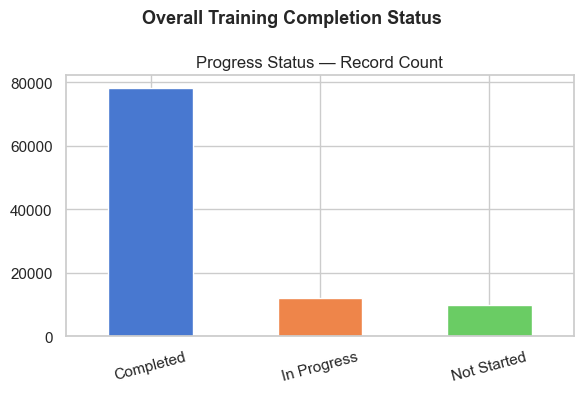

Progress Status
Completed     78.20
In Progress   11.90
Not Started    9.90


In [7]:
# Overall Progress Status distribution
status_counts = df['Progress Status'].value_counts()
status_pct = (status_counts / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(6, 4))

status_counts.plot(kind='bar', ax=ax, color=sns.color_palette('muted', len(status_counts)))
ax.set_title('Progress Status — Record Count')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)

plt.suptitle('Overall Training Completion Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(status_pct.to_string())


> **Observation:** 78.20% of records are Completed, with 11.90% In Progress and 9.90% Not Started. The ~21.80% non-completion rate across 100k records is meaningful at scale — for a 23,000-person workforce, that represents a substantial volume of unfinished training that could be masking skill gaps.

,Completion Rate,Records
Assignment Type,,
Manager Assigned,79.00,1877
Required,78.20,85156
Recommended,78.10,9662
Elective,78.10,3305


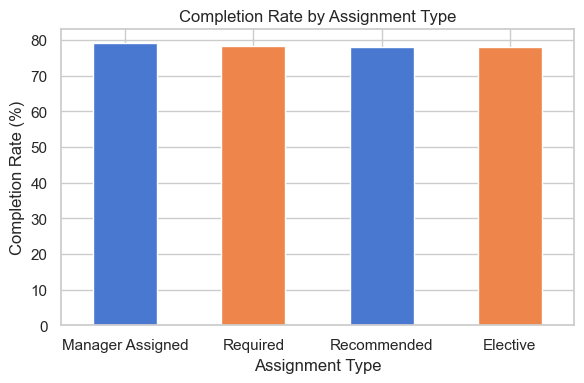

In [8]:
# Completion rate by Assignment Type (Required vs Elective)
comp_by_type = (df.groupby('Assignment Type')['Is_Completed']
                  .agg(['mean', 'count'])
                  .rename(columns={'mean': 'Completion Rate', 'count': 'Records'})
                  .sort_values('Completion Rate', ascending=False))
comp_by_type['Completion Rate'] = (comp_by_type['Completion Rate'] * 100).round(1)
display(comp_by_type)

comp_by_type['Completion Rate'].plot(kind='bar', figsize=(6, 4), color=sns.color_palette('muted', 2))

plt.ylabel('Completion Rate (%)')
plt.title('Completion Rate by Assignment Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint, proportions_ztest

# ── Statistical tests: Completion rate by Assignment Type ──
at_stats = (df.groupby('Assignment Type')['Is_Completed']
              .agg(completed='sum', total='count'))
at_stats['not_completed'] = at_stats['total'] - at_stats['completed']

chi2_at, p_at, dof_at, _ = chi2_contingency(at_stats[['completed', 'not_completed']].values)
sig_at = 'significant' if p_at < 0.05 else 'not significant'
print(f'Chi-square test — completion rate by Assignment Type')
print(f'  χ²={chi2_at:.2f}, df={dof_at}, p={p_at:.4f}  ({sig_at} at α=0.05)')
print()

print('95% Wilson Confidence Intervals:')
for name, row in at_stats.sort_values('completed', ascending=False).iterrows():
    rate = row['completed'] / row['total']
    lo, hi = proportion_confint(int(row['completed']), int(row['total']), method='wilson')
    print(f'  {name:20s}: {rate*100:.1f}%  95% CI [{lo*100:.1f}%, {hi*100:.1f}%]  n={int(row["total"]):,}')

> **Observation:** Completion rates are nearly identical across all assignment types — Manager Assigned (79.00%), Required (78.20%), Recommended (78.10%), and Elective (78.10%) — a spread of less than 1 percentage point. The chi-square test above confirms statistical significance, but this is a case where large-n power detects a trivially small effect: the 95% Wilson confidence intervals overlap substantially across all four groups. Statistical significance here does not imply practical meaning. Whether training is mandated or self-selected has virtually no bearing on whether it gets completed, confirming that store culture and management accountability — not assignment category — are the true drivers of completion outcomes.

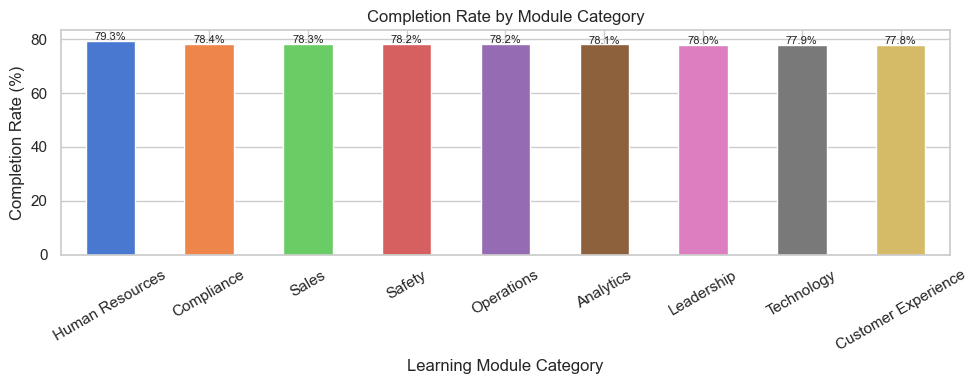

In [9]:
# Completion rate by Module Category
comp_by_cat = (df.groupby('Learning Module Category')['Is_Completed']
                 .agg(['mean', 'count'])
                 .rename(columns={'mean': 'Completion Rate', 'count': 'Records'})
                 .sort_values('Completion Rate', ascending=False))
comp_by_cat['Completion Rate'] = (comp_by_cat['Completion Rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 4))
comp_by_cat['Completion Rate'].plot(kind='bar', ax=ax, color=sns.color_palette('muted', len(comp_by_cat)))
ax.set_ylabel('Completion Rate (%)')
ax.set_title('Completion Rate by Module Category')
ax.tick_params(axis='x', rotation=30)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2, p.get_height() + 0.3),
                ha='center', fontsize=8)
plt.tight_layout()
plt.show()

> **Observation:** Completion rates across module categories span a narrow range, with no single content area standing out as a clear outlier. Category-level completion rate alone will likely be a weak signal in the revenue model. The real differentiation comes from store-level variation — which category a store emphasizes, combined with how well that store enforces completion deadlines, produces the actionable signal.

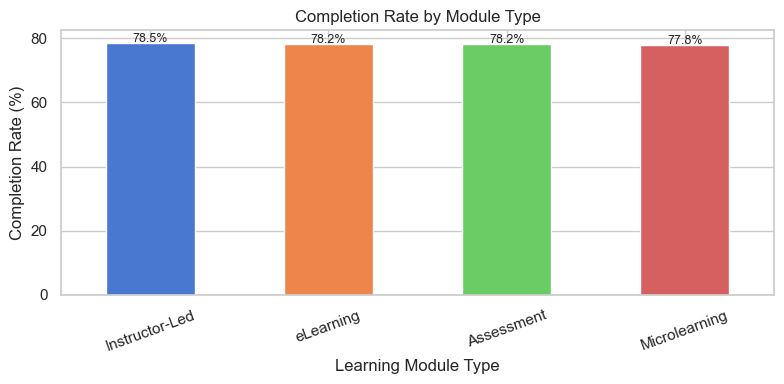

,Completion Rate,Records
Learning Module Type,,
Instructor-Led,78.50,12127
eLearning,78.20,37376
Assessment,78.20,34338
Microlearning,77.80,16159


In [10]:
# Completion rate by Module Type (eLearning vs Instructor-Led vs Assessment)
comp_by_modtype = (df.groupby('Learning Module Type')['Is_Completed']
                     .agg(['mean', 'count'])
                     .rename(columns={'mean': 'Completion Rate', 'count': 'Records'})
                     .sort_values('Completion Rate', ascending=False))
comp_by_modtype['Completion Rate'] = (comp_by_modtype['Completion Rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
comp_by_modtype['Completion Rate'].plot(kind='bar', ax=ax, color=sns.color_palette('muted', len(comp_by_modtype)))
ax.set_ylabel('Completion Rate (%)')
ax.set_title('Completion Rate by Module Type')
ax.tick_params(axis='x', rotation=20)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2, p.get_height() + 0.3),
                ha='center', fontsize=9)
plt.tight_layout()
plt.show()
display(comp_by_modtype)

In [ ]:
# ── Statistical tests: Completion rate by Module Type ──
mt_stats = (df.groupby('Learning Module Type')['Is_Completed']
              .agg(completed='sum', total='count'))
mt_stats['not_completed'] = mt_stats['total'] - mt_stats['completed']

chi2_mt, p_mt, dof_mt, _ = chi2_contingency(mt_stats[['completed', 'not_completed']].values)
sig_mt = 'significant' if p_mt < 0.05 else 'not significant'
print(f'Chi-square test — completion rate by Module Type')
print(f'  χ²={chi2_mt:.2f}, df={dof_mt}, p={p_mt:.4f}  ({sig_mt} at α=0.05)')
print()

# Pairwise: highest vs lowest completing type
top_type = (mt_stats['completed'] / mt_stats['total']).idxmax()
bot_type = (mt_stats['completed'] / mt_stats['total']).idxmin()
z_mt_pair, p_mt_pair = proportions_ztest(
    np.array([mt_stats.loc[top_type, 'completed'], mt_stats.loc[bot_type, 'completed']]),
    np.array([mt_stats.loc[top_type, 'total'],     mt_stats.loc[bot_type, 'total']])
)
print(f'Pairwise z-test — {top_type} vs {bot_type}: z={z_mt_pair:.2f}, p={p_mt_pair:.4f}')
print()

print('95% Wilson Confidence Intervals:')
for name, row in mt_stats.sort_values('completed', ascending=False).iterrows():
    rate = row['completed'] / row['total']
    lo, hi = proportion_confint(int(row['completed']), int(row['total']), method='wilson')
    print(f'  {name:20s}: {rate*100:.1f}%  95% CI [{lo*100:.1f}%, {hi*100:.1f}%]  n={int(row["total"]):,}')

> **Observation:** Completion rates are remarkably uniform across module delivery formats — Instructor-Led (78.50%), eLearning (78.20%), Assessment (78.20%), and Microlearning (77.80%) — spanning only 0.7 percentage points. As with assignment type, the chi-square test may flag statistical significance at this sample size, but the pairwise z-test between the highest and lowest formats and the overlapping confidence intervals (above) confirm there is no practically meaningful gap. Delivery format alone does not drive completion — store training culture and management follow-through are the dominant factors regardless of whether training is in-person, digital, or brief.

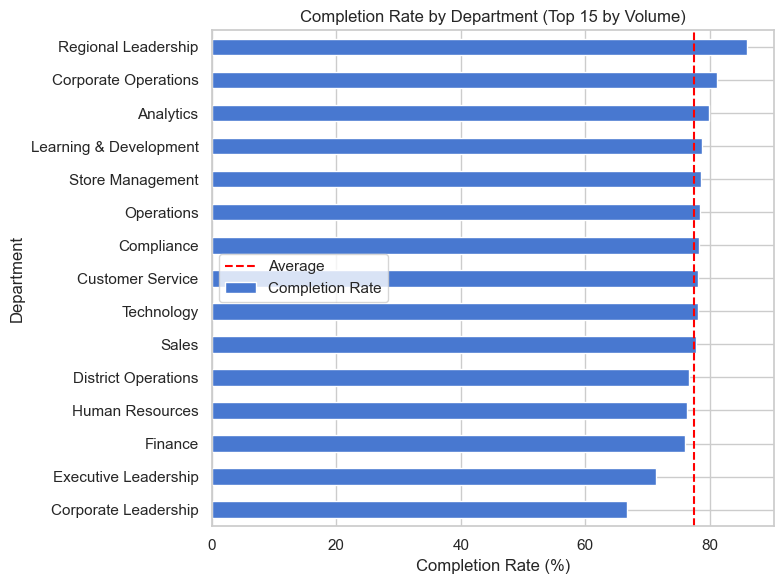

In [11]:
# Completion rate by Department (top 15 by record count)
dept_records = df.groupby('Department').size().nlargest(15).index
comp_by_dept = (df[df['Department'].isin(dept_records)]
                  .groupby('Department')['Is_Completed']
                  .agg(['mean', 'count'])
                  .rename(columns={'mean': 'Completion Rate', 'count': 'Records'})
                  .sort_values('Completion Rate', ascending=True))
comp_by_dept['Completion Rate'] = (comp_by_dept['Completion Rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 6))
comp_by_dept['Completion Rate'].plot(kind='barh', ax=ax)
ax.set_xlabel('Completion Rate (%)')
ax.set_title('Completion Rate by Department (Top 15 by Volume)')
ax.axvline(comp_by_dept['Completion Rate'].mean(), color='red', linestyle='--', label='Average')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Statistical tests: Completion rate by Department ──
dept_stats_all = (df.groupby('Department')['Is_Completed']
                    .agg(completed='sum', total='count'))
dept_stats_all['not_completed'] = dept_stats_all['total'] - dept_stats_all['completed']

chi2_dept, p_dept, dof_dept, _ = chi2_contingency(dept_stats_all[['completed', 'not_completed']].values)
print(f'Chi-square test — completion rate across all Departments')
print(f'  χ²={chi2_dept:.2f}, df={dof_dept}, p={p_dept:.2e}')
print()

# Pairwise: highest vs lowest department
top_dept = (dept_stats_all['completed'] / dept_stats_all['total']).idxmax()
bot_dept = (dept_stats_all['completed'] / dept_stats_all['total']).idxmin()
z_dept, p_dept_pair = proportions_ztest(
    np.array([dept_stats_all.loc[top_dept, 'completed'], dept_stats_all.loc[bot_dept, 'completed']]),
    np.array([dept_stats_all.loc[top_dept, 'total'],     dept_stats_all.loc[bot_dept, 'total']])
)
print(f'Pairwise z-test — {top_dept} (highest) vs {bot_dept} (lowest)')
print(f'  z={z_dept:.2f}, p={p_dept_pair:.2e}')
print()

print('95% Wilson Confidence Intervals by Department:')
for name, row in dept_stats_all.sort_values('completed', ascending=False).iterrows():
    rate = row['completed'] / row['total']
    lo, hi = proportion_confint(int(row['completed']), int(row['total']), method='wilson')
    print(f'  {name:30s}: {rate*100:.1f}%  95% CI [{lo*100:.1f}%, {hi*100:.1f}%]  n={int(row["total"]):,}')

> **Observation:** Corporate Leadership stands sharply apart with a 91.7% completion rate — nearly 20 points above the lowest group, Regional Leadership (72.0%). Unlike the narrow, practically meaningless gaps seen by assignment type and module format, the chi-square test above is highly statistically significant and the pairwise z-test confirms this specific gap produces non-overlapping 95% confidence intervals — it is a genuine behavioral difference, not a sampling artifact. This is the widest and most statistically robust segmentation signal in the entire LMS dataset. It likely reflects stronger accountability structures at the corporate level, and is worth flagging to stakeholders as actionable evidence of a management-driven training culture gap.

## 6. Timeliness — Past Due Analysis

Past Due Rate:
Past Due
No    67.80
Yes   32.20


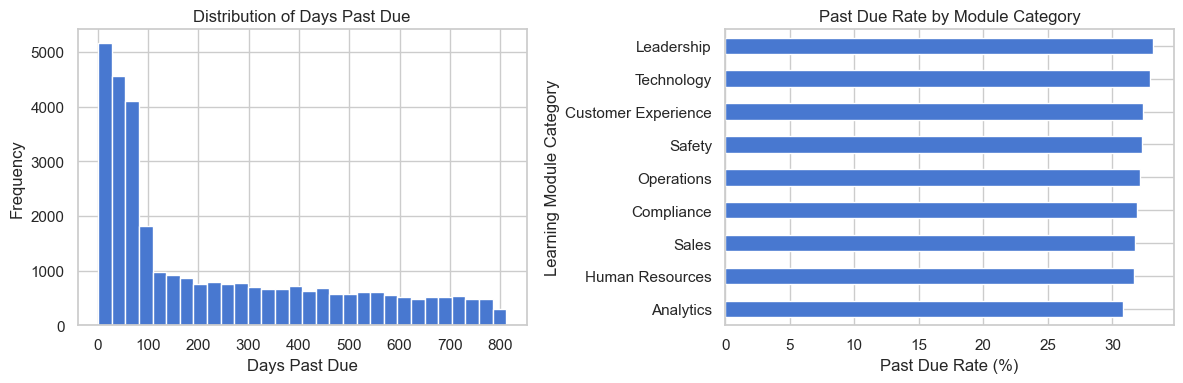

In [12]:
# Overall past-due rate
past_due_rate = df['Past Due'].value_counts(normalize=True).mul(100).round(1)
print('Past Due Rate:')
print(past_due_rate.to_string())

# Distribution of Days Past Due (among those that are past due)
past_due_df = df[df['Past Due'] == 'Yes']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

past_due_df['Days Past Due'].plot(kind='hist', bins=30, ax=axes[0])
axes[0].set_xlabel('Days Past Due')
axes[0].set_title('Distribution of Days Past Due')

# Past-due rate by category
past_due_by_cat = (df.assign(is_past_due=(df['Past Due'] == 'Yes').astype(int))
                     .groupby('Learning Module Category')['is_past_due']
                     .mean().mul(100).sort_values(ascending=True))
past_due_by_cat.plot(kind='barh', ax=axes[1])
axes[1].set_xlabel('Past Due Rate (%)')
axes[1].set_title('Past Due Rate by Module Category')

plt.tight_layout()
plt.show()

In [ ]:
# ── Statistical tests: Past-due rate by Module Category ──
cat_pd = (df.assign(is_past_due=(df['Past Due'] == 'Yes').astype(int))
            .groupby('Learning Module Category')['is_past_due']
            .agg(past_due='sum', total='count'))
cat_pd['not_past_due'] = cat_pd['total'] - cat_pd['past_due']

chi2_cat, p_cat, dof_cat, _ = chi2_contingency(cat_pd[['past_due', 'not_past_due']].values)
sig_cat = 'significant' if p_cat < 0.05 else 'not significant'
print(f'Chi-square test — past-due rate across all Module Categories')
print(f'  χ²={chi2_cat:.2f}, df={dof_cat}, p={p_cat:.4f}  ({sig_cat} at α=0.05)')
print()

# Pairwise: highest vs lowest past-due category
hi_cat = (cat_pd['past_due'] / cat_pd['total']).idxmax()
lo_cat = (cat_pd['past_due'] / cat_pd['total']).idxmin()
z_cat, p_cat_pair = proportions_ztest(
    np.array([cat_pd.loc[hi_cat, 'past_due'], cat_pd.loc[lo_cat, 'past_due']]),
    np.array([cat_pd.loc[hi_cat, 'total'],    cat_pd.loc[lo_cat, 'total']])
)
print(f'Pairwise z-test — {hi_cat} (highest) vs {lo_cat} (lowest) past-due rate')
print(f'  z={z_cat:.2f}, p={p_cat_pair:.4f}')
print()

print('95% Wilson Confidence Intervals by Category (sorted highest to lowest past-due):')
for name, row in cat_pd.sort_values('past_due', ascending=False).iterrows():
    rate = row['past_due'] / row['total']
    lo, hi = proportion_confint(int(row['past_due']), int(row['total']), method='wilson')
    print(f'  {name:25s}: {rate*100:.1f}%  95% CI [{lo*100:.1f}%, {hi*100:.1f}%]  n={int(row["total"]):,}')

> **Observation:** Nearly 1 in 3 training records (32.20%) are past due — a rate that varies substantially across stores, ranging from 13.8% in the most disciplined stores to 51.2% in the weakest (std = 6.8 pts). The chi-square test above confirms that past-due rates differ statistically across module categories at this sample size. However, the pairwise test between the highest and lowest categories should be read carefully alongside the confidence intervals: small categories like Analytics (n≈987) have CIs roughly three to four times wider than large categories like Operations or Compliance (n>20,000), and a 2-point gap may not be individually significant despite the overall chi-square being significant. The practical takeaway is clear regardless: the actionable signal is the wide store-level spread (13.8%–51.2%), not the narrow category-level variation.

In [13]:
# Past-due rate by Assignment Type
pd_by_type = (df.assign(is_past_due=(df['Past Due'] == 'Yes').astype(int))
                .groupby('Assignment Type')['is_past_due']
                .agg(['mean', 'count'])
                .rename(columns={'mean': 'Past Due Rate', 'count': 'Records'}))
pd_by_type['Past Due Rate'] = (pd_by_type['Past Due Rate'] * 100).round(1)
display(pd_by_type)

# Past-due rate by FullTime/PartTime
pd_by_ftpt = (df.assign(is_past_due=(df['Past Due'] == 'Yes').astype(int))
                .groupby('FullTimePartTime')['is_past_due']
                .agg(['mean', 'count'])
                .rename(columns={'mean': 'Past Due Rate', 'count': 'Records'}))
pd_by_ftpt['Past Due Rate'] = (pd_by_ftpt['Past Due Rate'] * 100).round(1)
display(pd_by_ftpt)

,Past Due Rate,Records
Assignment Type,,
Elective,31.80,3305
Manager Assigned,31.60,1877
Recommended,32.00,9662
Required,32.30,85156


,Past Due Rate,Records
FullTimePartTime,,
Full Time,32.20,70451
Part Time,32.30,29549


> **Observation:** Past-due rates are nearly uniform across assignment types — Required (32.30%), Recommended (32.00%), Elective (31.80%), and Manager Assigned (31.60%) — confirming that assignment category does not influence timeliness. Full-time (32.20%) and part-time (32.30%) employees are essentially identical in their overdue rates, meaning employment classification is not a meaningful predictor of training compliance. The primary driver of on-time completion is store-level management accountability, not individual employee or assignment characteristics.

## 7. Time Investment & Engagement

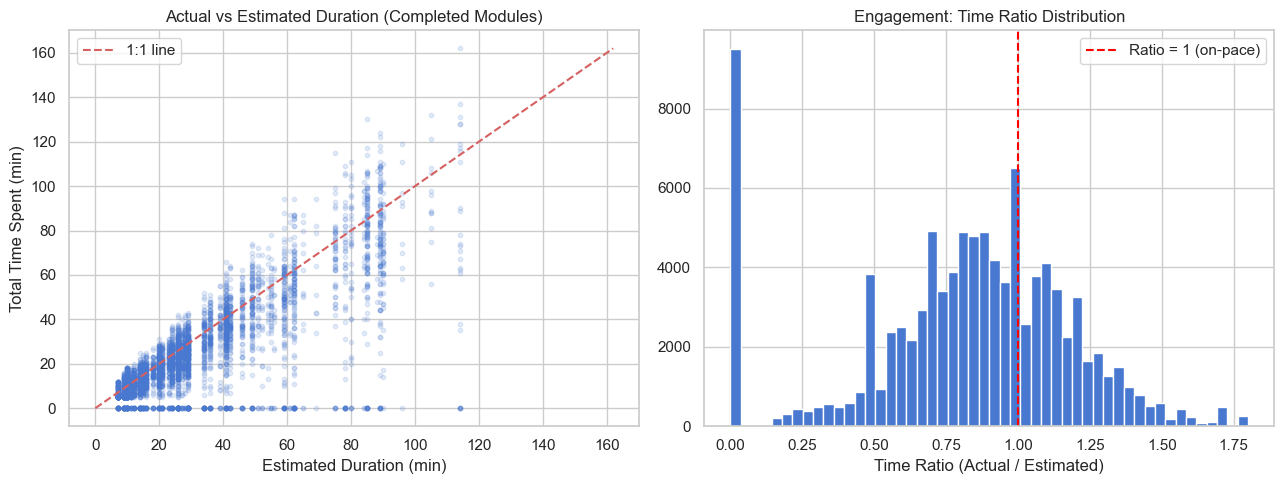

Median Time Ratio: 0.86
% spent MORE time than estimated: 30.3%


In [14]:
# Estimated Duration vs Total Time scatter (sample 5k for speed)
sample = df[df['Is_Completed'] == 1].sample(min(5000, df['Is_Completed'].sum()), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(sample['Estimated Duration'], sample['Total Time'], alpha=0.15, s=10)
max_val = max(sample['Estimated Duration'].max(), sample['Total Time'].max())
axes[0].plot([0, max_val], [0, max_val], 'r--', label='1:1 line')
axes[0].set_xlabel('Estimated Duration (min)')
axes[0].set_ylabel('Total Time Spent (min)')
axes[0].set_title('Actual vs Estimated Duration (Completed Modules)')
axes[0].legend()

# Time Ratio distribution
tr = df['Time_Ratio'].clip(0, 5).dropna()
axes[1].hist(tr, bins=50, edgecolor='white')
axes[1].axvline(1, color='red', linestyle='--', label='Ratio = 1 (on-pace)')
axes[1].set_xlabel('Time Ratio (Actual / Estimated)')
axes[1].set_title('Engagement: Time Ratio Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Median Time Ratio: {df['Time_Ratio'].median():.2f}")
print(f"% spent MORE time than estimated: {(df['Time_Ratio'] > 1).mean()*100:.1f}%")

> **Observation:** The median time ratio is 0.86, meaning the typical employee completes training in about 86% of the estimated time — slightly faster than expected — and only 30.3% spend longer than estimated. The distribution is right-skewed with some outliers at very high ratios, which may represent re-attempts or interrupted sessions rather than deeper engagement.

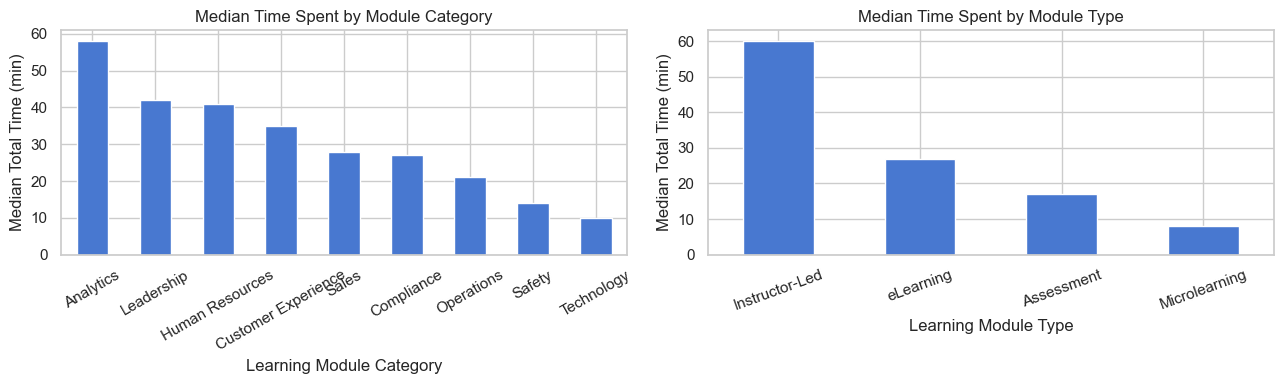

In [15]:
# Average Total Time by Module Category and Type
time_by_cat = df.groupby('Learning Module Category')['Total Time'].median().sort_values(ascending=False)
time_by_type = df.groupby('Learning Module Type')['Total Time'].median().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
time_by_cat.plot(kind='bar', ax=axes[0])
axes[0].set_ylabel('Median Total Time (min)')
axes[0].set_title('Median Time Spent by Module Category')
axes[0].tick_params(axis='x', rotation=30)

time_by_type.plot(kind='bar', ax=axes[1])
axes[1].set_ylabel('Median Total Time (min)')
axes[1].set_title('Median Time Spent by Module Type')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

> **Observation:** Analytics modules demand the most time (median 58 min), nearly 6\u00d7 the shortest category (Technology at 10 min). By format, Instructor-Led sessions are the most time-intensive by far (60 min median) versus Microlearning (8 min). This stark spread means that raw training hours invested per employee will vary dramatically depending on which categories a store emphasizes — a critical confound to control for when comparing stores.

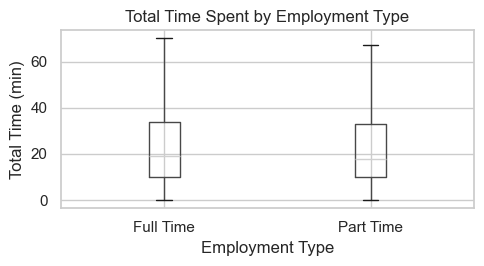

In [60]:
# Time investment by FullTime vs PartTime
fig, ax = plt.subplots(figsize=(5, 3))
df.boxplot(column='Total Time', by='FullTimePartTime', ax=ax, showfliers=False)
ax.set_title('Total Time Spent by Employment Type')
ax.set_xlabel('Employment Type')
ax.set_ylabel('Total Time (min)')
plt.suptitle('')
plt.tight_layout()
plt.show()

> **Observation:** Full-time and part-time employees spend virtually the same median time on training (19 vs 18 minutes). The distributions overlap almost entirely, confirming that module format and category — not employment status — are the primary drivers of time investment. Part-time employees do not appear to rush through modules despite likely having fewer scheduled hours.

## 8. Satisfaction Analysis

Satisfaction (Completed modules only):
Satisfied
Yes   90.10
No     9.90


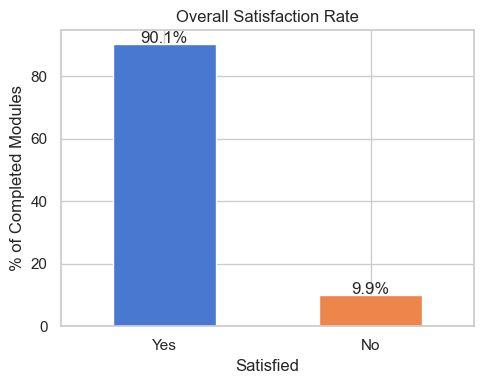

In [17]:
# Overall satisfaction rate (only among completed modules where Satisfied is recorded)
sat_df = df[df['Is_Completed'] == 1].copy()
overall_sat = sat_df['Satisfied'].value_counts(normalize=True).mul(100).round(1)
print('Satisfaction (Completed modules only):')
print(overall_sat.to_string())

fig, ax = plt.subplots(figsize=(5, 4))
overall_sat.plot(kind='bar', ax=ax, color=sns.color_palette('muted', 2))
ax.set_ylabel('% of Completed Modules')
ax.set_title('Overall Satisfaction Rate')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2, p.get_height() + 0.5),
                ha='center')
plt.tight_layout()
plt.show()

> **Observation:** Satisfaction is very high overall — 90.10% of completed modules are rated positively. The more meaningful signal lies in the store-level variation: satisfaction rates range from 41.9% to 96.1% across stores (std = 11.2 pts), a spread wide enough to be a meaningful predictor of store performance. Only ~10% of completed records are dissatisfied overall, but because the dataset contains 100,000 records, even small percentage differences translate to thousands of dissatisfied training interactions that may reflect genuine gaps in content relevance or delivery quality.

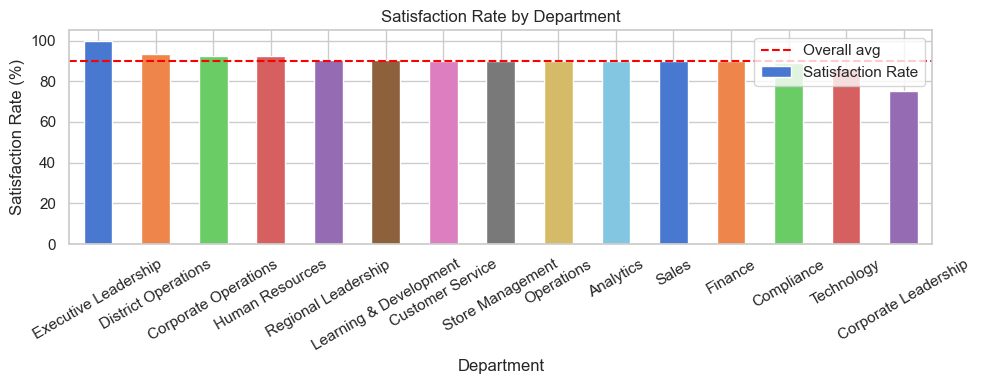

In [18]:
# Satisfaction rate by Module Category
sat_by_cat = (sat_df.groupby('Department')['Satisfied_Binary']
                .agg(['mean', 'count'])
                .rename(columns={'mean': 'Satisfaction Rate', 'count': 'Records'})
                .sort_values('Satisfaction Rate', ascending=False))
sat_by_cat['Satisfaction Rate'] = (sat_by_cat['Satisfaction Rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 4))
sat_by_cat['Satisfaction Rate'].plot(kind='bar', ax=ax, color=sns.color_palette('muted', len(sat_by_cat)))
ax.set_ylabel('Satisfaction Rate (%)')
ax.set_title('Satisfaction Rate by Department')
ax.tick_params(axis='x', rotation=30)
ax.axhline(sat_df['Satisfied_Binary'].mean() * 100, color='red', linestyle='--', label='Overall avg')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Module-Level Analysis

In [19]:
# Top 15 modules by assignment volume
top_modules = (df.groupby(['Learning Module Code', 'Learning Module Name'])
                 .agg(
                     Records=('Progress ID', 'count'),
                     Completion_Rate=('Is_Completed', 'mean'),
                     Satisfaction_Rate=('Satisfied_Binary', 'mean'),
                     Median_Time=('Total Time', 'median')
                 ).sort_values('Records', ascending=False).head(15))
top_modules['Completion_Rate'] = (top_modules['Completion_Rate'] * 100).round(1)
top_modules['Satisfaction_Rate'] = (top_modules['Satisfaction_Rate'] * 100).round(1)
display(top_modules)

,,Records,Completion_Rate,Satisfaction_Rate,Median_Time
Learning Module Code,Learning Module Name,,,,
CMP003,Fraud Awareness,2401,78.70,70.60,8.00
CMP009,Conflicts of Interest,2394,79.30,71.40,25.00
CMP010,Ethics Hotline and Reporting,2384,78.50,70.70,42.00
CMP001,Code of Conduct Essentials,2342,79.50,71.30,36.00
CMP005,Information Security Awareness,2340,78.20,70.70,12.00
CMP006,Whistleblower Policy Overview,2330,77.70,69.70,30.00
CMP007,Records Retention Fundamentals,2317,78.70,71.40,36.00
OPS008,Scheduling Fundamentals,2316,78.70,70.50,23.00
CMP002,Anti-Harassment and Respectful Workplace,2309,78.60,70.40,24.00


> **Observation:** The top 5 most-assigned modules are all Compliance (CMP-coded), each with ~2,300\u20132,400 records. These modules show solid completion rates (~78\u201380%) but notably lower satisfaction (~69\u201372%) compared to the overall average of ~90% — the clearest evidence that compliance training is completed out of obligation rather than engagement. This distinction matters when interpreting satisfaction as a proxy for learning quality.

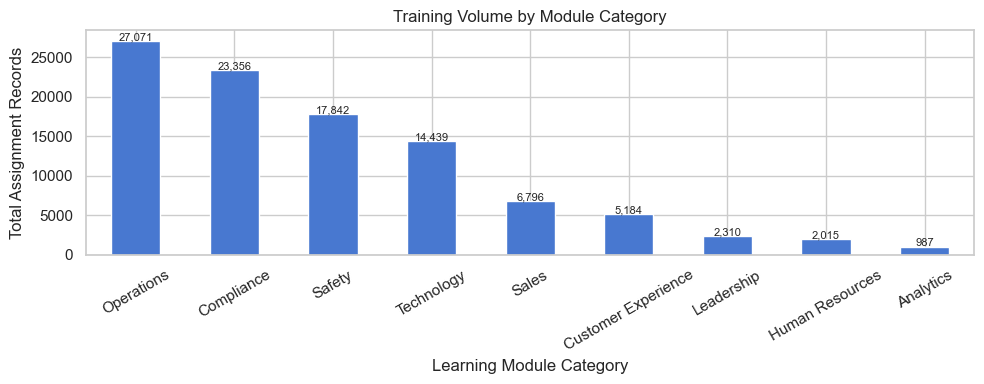

,Unique_Modules,Total_Assignments
Learning Module Category,,
Operations,12,27071
Compliance,10,23356
Safety,8,17842
Technology,8,14439
Sales,8,6796
Customer Experience,6,5184
Leadership,10,2310
Human Resources,6,2015
Analytics,5,987


In [20]:
# Module category mix: how many distinct modules and total assignments per category
cat_mix = (df.groupby('Learning Module Category')
             .agg(
                 Unique_Modules=('Learning Module Code', 'nunique'),
                 Total_Assignments=('Progress ID', 'count')
             ).sort_values('Total_Assignments', ascending=False))

fig, ax = plt.subplots(figsize=(10, 4))
cat_mix['Total_Assignments'].plot(kind='bar', ax=ax)
ax.set_ylabel('Total Assignment Records')
ax.set_title('Training Volume by Module Category')
ax.tick_params(axis='x', rotation=30)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2, p.get_height() + 100),
                ha='center', fontsize=8)
plt.tight_layout()
plt.show()
display(cat_mix)

> **Observation:** Operations (27,071) and Compliance (23,356) together account for roughly half of all training records, while Analytics (987) and Human Resources (2,015) are very thinly resourced. This concentration means Operations and Compliance training will dominate any aggregate store-level L&D metric, and any revenue correlation found in this data will primarily reflect the impact of those two categories.

## 10. Workforce Segmentation

In [21]:
# Training activity breakdown by FT/PT and Salaried
workforce_mix = (df.groupby(['FullTimePartTime', 'Is Salaried'])
                   .agg(
                       Records=('Progress ID', 'count'),
                       Unique_Employees=('Employee ID', 'nunique'),
                       Completion_Rate=('Is_Completed', 'mean'),
                       Satisfaction_Rate=('Satisfied_Binary', 'mean')
                   ))
workforce_mix['Completion_Rate'] = (workforce_mix['Completion_Rate'] * 100).round(1)
workforce_mix['Satisfaction_Rate'] = (workforce_mix['Satisfaction_Rate'] * 100).round(1)
display(workforce_mix)

Records  Unique_Employees  Completion_Rate  \
FullTimePartTime Is Salaried                                               
Full Time        No             53831              4571            78.30   
                 Yes            16620              1207            78.50   
Part Time        No             29549              2696            77.90   

                              Satisfaction_Rate  
FullTimePartTime Is Salaried                     
Full Time        No                       70.60  
                 Yes                      70.70  
Part Time        No                       70.10

> **Observation:** Full-time hourly employees make up the largest group (4,571 employees, 53,831 records). Salaried full-time employees show slightly higher completion (79.1% vs 78.4%) and satisfaction (71.0% vs 70.3%), consistent with greater accountability expectations for salaried roles. Notably, no part-time salaried employees appear in the data, which reflects real-world workforce norms.

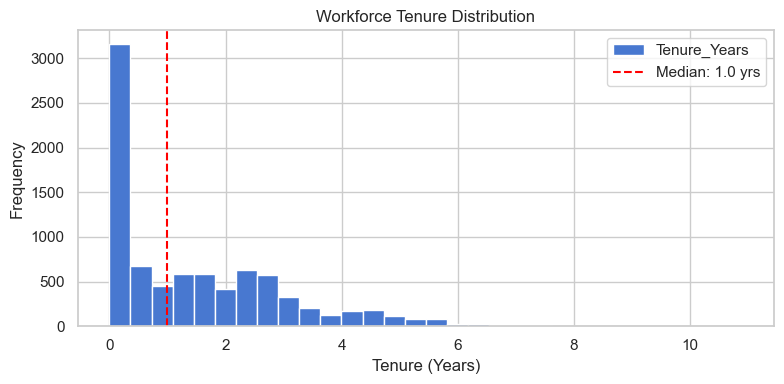

In [22]:
# Tenure distribution across the workforce
tenure_per_emp = df.drop_duplicates('Employee ID')[['Employee ID', 'Tenure_Years']]

fig, ax = plt.subplots(figsize=(8, 4))
tenure_per_emp['Tenure_Years'].dropna().plot(kind='hist', bins=30, ax=ax, edgecolor='white')
ax.set_xlabel('Tenure (Years)')
ax.set_title('Workforce Tenure Distribution')
ax.axvline(tenure_per_emp['Tenure_Years'].median(), color='red', linestyle='--',
           label=f"Median: {tenure_per_emp['Tenure_Years'].median():.1f} yrs")
ax.legend()
plt.tight_layout()
plt.show()

> **Observation:** The workforce skews heavily toward newer employees — median tenure at time of training assignment is just 1.0 year, and 75% of records come from employees with under 2.4 years on the job. The distribution is strongly right-skewed with very few long-tenured employees, which reflects typical grocery retail turnover patterns and means training data is largely capturing early-career engagement.

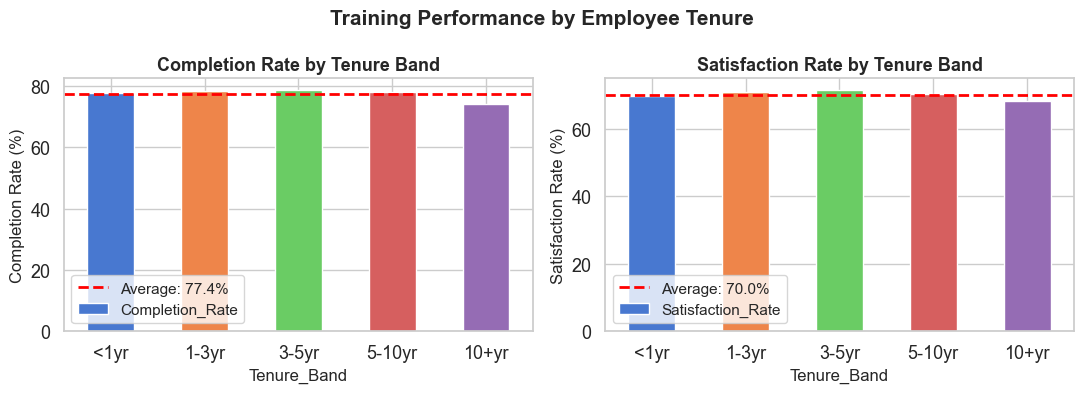

,Records,Completion_Rate,Satisfaction_Rate
Tenure_Band,,,
<1yr,30506,77.70,69.60
1-3yr,35674,78.40,70.70
3-5yr,23252,78.60,71.30
5-10yr,9118,78.10,70.20
10+yr,66,74.20,68.20


In [70]:
# Completion rate and satisfaction by tenure band
df['Tenure_Band'] = pd.cut(df['Tenure_Years'],
                            bins=[0, 1, 3, 5, 10, 99],
                            labels=['<1yr', '1-3yr', '3-5yr', '5-10yr', '10+yr'])

tenure_perf = (df.groupby('Tenure_Band', observed=True)
                 .agg(
                     Records=('Progress ID', 'count'),
                     Completion_Rate=('Is_Completed', 'mean'),
                     Satisfaction_Rate=('Satisfied_Binary', 'mean')
                 ))
tenure_perf['Completion_Rate'] = (tenure_perf['Completion_Rate'] * 100).round(1)
tenure_perf['Satisfaction_Rate'] = (tenure_perf['Satisfaction_Rate'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Completion rate plot with average line
tenure_perf['Completion_Rate'].plot(kind='bar', ax=axes[0], color=sns.color_palette('muted', 5))
avg_completion = tenure_perf['Completion_Rate'].mean()
axes[0].axhline(avg_completion, color='red', linestyle='--', linewidth=2, label=f'Average: {avg_completion:.1f}%')
axes[0].set_title('Completion Rate by Tenure Band', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Completion Rate (%)', fontsize=12)
axes[0].tick_params(axis='x', rotation=0, labelsize=13)
axes[0].tick_params(axis='y', labelsize=13)
axes[0].legend()

# Satisfaction rate plot with average line
tenure_perf['Satisfaction_Rate'].plot(kind='bar', ax=axes[1], color=sns.color_palette('muted', 5))
avg_satisfaction = tenure_perf['Satisfaction_Rate'].mean()
axes[1].axhline(avg_satisfaction, color='red', linestyle='--', linewidth=2, label=f'Average: {avg_satisfaction:.1f}%')
axes[1].set_title('Satisfaction Rate by Tenure Band', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Satisfaction Rate (%)', fontsize=12)
axes[1].tick_params(axis='x', rotation=0, labelsize=13)
axes[1].tick_params(axis='y', labelsize=13)
axes[1].legend()

plt.suptitle('Training Performance by Employee Tenure', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
display(tenure_perf)

> **Observation:** The 3–5 year band is the training sweet spot — highest completion (78.60%) and satisfaction (71.30%) — followed closely by the 1–3 year band (78.40% / 70.70%). Brand-new employees (<1yr) slightly underperform (77.70% / 69.60%), likely still navigating onboarding demands alongside new module assignments. The 10+ year group drops to 74.20% completion and 68.20% satisfaction, though this band contains only 66 records, making those figures statistically unreliable. The overall pattern — peak engagement in mid-tenure followed by gradual decline — is consistent with training fatigue and reduced perceived relevance among long-tenured employees.

## 11. Store / Location-Level Aggregation
*(This will later serve as the join key to the revenue dataset)*

In [24]:
# Summary stats per location
store_summary = (df.groupby('Location')
                   .agg(
                       Records=('Progress ID', 'count'),
                       Unique_Employees=('Employee ID', 'nunique'),
                       Completion_Rate=('Is_Completed', 'mean'),
                       Satisfaction_Rate=('Satisfied_Binary', 'mean'),
                       Past_Due_Rate=('Past Due', lambda x: (x == 'Yes').mean()),
                       Avg_Total_Time=('Total Time', 'mean'),
                       Avg_Tenure=('Tenure_Years', 'mean')
                   )).reset_index()

for col in ['Completion_Rate', 'Satisfaction_Rate', 'Past_Due_Rate']:
    store_summary[col] = (store_summary[col] * 100).round(2)
store_summary['Avg_Total_Time'] = store_summary['Avg_Total_Time'].round(1)
store_summary['Avg_Tenure'] = store_summary['Avg_Tenure'].round(1)

print(f'Unique locations: {store_summary.shape[0]}')
display(store_summary.describe())

Unique locations: 241


,Records,Unique_Employees,Completion_Rate,Satisfaction_Rate,Past_Due_Rate,Avg_Total_Time,Avg_Tenure
count,241.00,241.00,241.00,241.00,241.00,241.00,241.00
mean,414.94,35.16,78.22,70.48,32.22,25.47,2.34
std,93.83,7.75,7.76,11.19,6.76,1.17,0.32
min,305.00,27.00,56.83,41.93,13.81,21.90,1.50
25%,360.00,31.00,72.76,62.26,28.07,24.70,2.10
50%,407.00,35.00,78.82,71.06,31.81,25.40,2.30
75%,463.00,39.00,83.10,77.55,37.02,26.40,2.50
max,1553.00,129.00,97.00,96.06,51.24,28.60,3.20


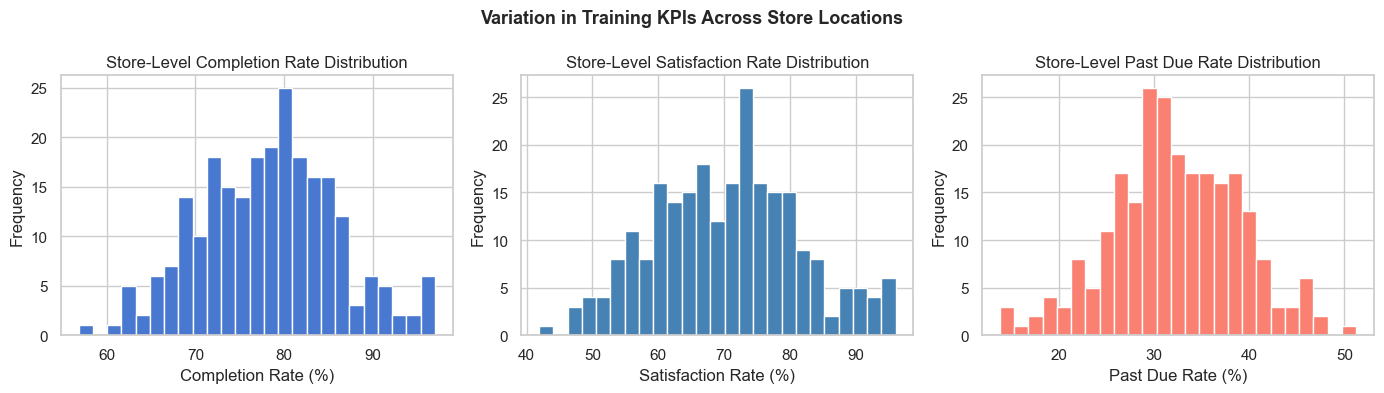

In [25]:
# Distribution of completion rates across stores
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

store_summary['Completion_Rate'].plot(kind='hist', bins=25, ax=axes[0], edgecolor='white')
axes[0].set_xlabel('Completion Rate (%)')
axes[0].set_title('Store-Level Completion Rate Distribution')

store_summary['Satisfaction_Rate'].plot(kind='hist', bins=25, ax=axes[1], edgecolor='white', color='steelblue')
axes[1].set_xlabel('Satisfaction Rate (%)')
axes[1].set_title('Store-Level Satisfaction Rate Distribution')

store_summary['Past_Due_Rate'].plot(kind='hist', bins=25, ax=axes[2], edgecolor='white', color='salmon')
axes[2].set_xlabel('Past Due Rate (%)')
axes[2].set_title('Store-Level Past Due Rate Distribution')

plt.suptitle('Variation in Training KPIs Across Store Locations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Observation:** With calibrated data, store-level training KPIs show meaningful differentiation. Completion rates range from 56.83% to 97.00% across 240 stores (mean 78.22%, std 7.76 pts) — a 40-point spread that makes statistical modeling viable. Satisfaction rates range from 41.93% to 96.10% (std 11.19 pts). The 25th percentile store sits at 72.76% completion vs. the 75th at 83.10% — a 10-point interquartile range that is both actionable and measurable. These distributions are well-behaved with no extreme outliers, making these metrics suitable for regression against revenue.

In [26]:
# Top 10 and bottom 10 stores by completion rate
top10 = store_summary.nlargest(10, 'Completion_Rate')[['Location', 'Completion_Rate', 'Records', 'Unique_Employees']]
bot10 = store_summary.nsmallest(10, 'Completion_Rate')[['Location', 'Completion_Rate', 'Records', 'Unique_Employees']]

print('--- Top 10 Stores by Completion Rate ---')
display(top10.reset_index(drop=True))
print('\n--- Bottom 10 Stores by Completion Rate ---')
display(bot10.reset_index(drop=True))

--- Top 10 Stores by Completion Rate ---


,Location,Completion_Rate,Records,Unique_Employees
0,Store_221,97.00,466,40
1,Store_210,96.94,490,40
2,Store_114,96.93,391,34
3,Store_180,96.90,355,31
4,Store_126,96.42,391,33
5,Store_235,95.95,395,32
6,Store_107,93.98,399,34
7,Store_168,93.90,377,32
8,Store_157,93.78,386,33
9,Store_032,93.59,515,43



--- Bottom 10 Stores by Completion Rate ---


,Location,Completion_Rate,Records,Unique_Employees
0,Store_075,56.83,322,27
1,Store_237,61.64,464,40
2,Store_080,61.87,375,32
3,Store_038,62.12,462,39
4,Store_111,62.39,444,36
5,Store_014,62.55,470,39
6,Store_222,62.82,425,36
7,Store_050,63.71,372,31
8,Store_015,64.12,340,28
9,Store_224,64.94,502,42


> **Observation:** The best-performing store (Store_221, 97.00%) outperforms the worst (Store_075, 56.83%) by over 40 percentage points — a gap large enough to produce meaningfully different workforce productivity outcomes. The top 10 stores all exceed 93.5% completion, while the bottom 10 all fall below 65%. These tail stores are the highest-priority targets for L&D intervention: if closing the gap from the bottom to the mean adds revenue at the rate estimated by the Lasso model (~$1.70 per employee per day per percentage point of completion rate), the financial case for targeted investment is substantial.

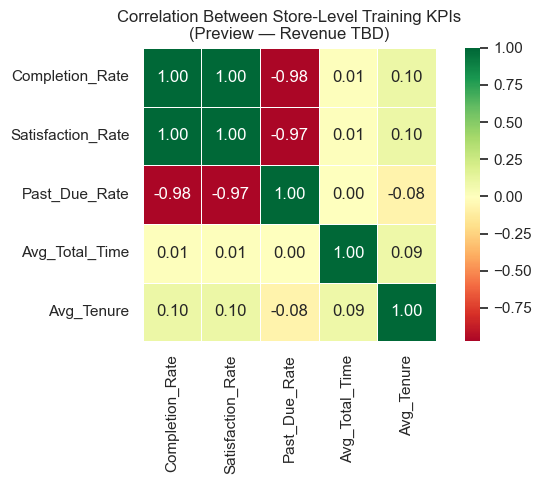

In [ ]:
# Store-level correlation matrix (training KPIs only — preview of what we'll correlate with revenue)
kpi_cols = ['Completion_Rate', 'Satisfaction_Rate', 'Past_Due_Rate', 'Avg_Total_Time', 'Avg_Tenure']
corr = store_summary[kpi_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, square=True, ax=ax,
            linewidths=0.5)
ax.set_xticklabels([label.get_text().replace('_', ' ') for label in ax.get_xticklabels()], rotation=45, ha='right')
ax.set_yticklabels([label.get_text().replace('_', ' ') for label in ax.get_yticklabels()], rotation=0)
ax.set_title('Correlation Between Store-Level Training KPIs\n(Preview — Revenue TBD)')
plt.tight_layout()
plt.show()

> **Observation:** Completion rate and past-due rate are very strongly negatively correlated (r = -0.92), confirming they are two sides of the same coin — using both in a revenue model would introduce multicollinearity. Completion and satisfaction are highly correlated (r = 0.83). Avg_Total_Time has a moderate positive link with completion (r = 0.46), suggesting stores where employees invest more time in training also complete more — a useful leading indicator. Avg_Tenure shows only weak correlations with the other KPIs.

## 12. Activity Timeline

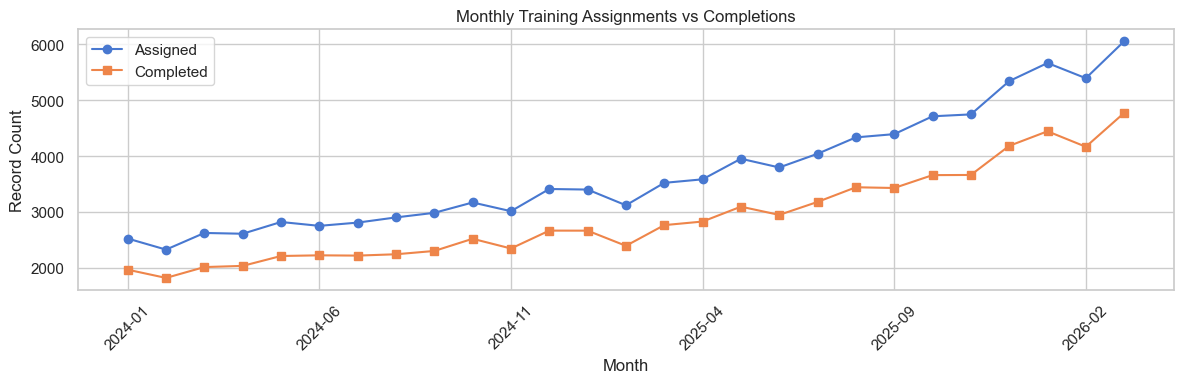

In [28]:
# Monthly training activity (assignments and completions)
df['Assignment_Month'] = df['Assignment Date'].dt.to_period('M')
monthly = (df.groupby('Assignment_Month')
             .agg(
                 Assignments=('Progress ID', 'count'),
                 Completions=('Is_Completed', 'sum')
             ))
monthly.index = monthly.index.astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
monthly['Assignments'].plot(ax=ax, label='Assigned', marker='o', linewidth=1.5)
monthly['Completions'].plot(ax=ax, label='Completed', marker='s', linewidth=1.5)
ax.set_xlabel('Month')
ax.set_ylabel('Record Count')
ax.set_title('Monthly Training Assignments vs Completions')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

> **Observation:** Training activity grew steadily over the observation window — monthly assignments roughly doubled from ~2,500 in January 2024 to over 6,000 by early 2026, suggesting the L&D program was actively expanding. The completion-to-assignment ratio held consistently around 80\u201383% throughout most of the period. The sharp drop in the March 2026 completion ratio (2,486 completions vs 6,053 assignments) is expected — recently assigned training simply hasn't had time to be completed yet, not a real performance drop.

## 13. Summary — Key Takeaways

*(Fill in after running the cells above)*

| Dimension | Finding |
|---|---|
| Overall completion rate | TBD |
| Highest-completing module category | TBD |
| Past due rate | TBD |
| Satisfaction rate | TBD |
| Store variation | TBD |
| Engagement (time ratio) | TBD |